# *Glass Identification* dataset

[*UCI* webpage](https://archive.ics.uci.edu/dataset/42/glass+identification)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last three lines are to customize the style of figures, especially adding a light gray grid and increasing the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

seaborn.set_theme(style="white",
                  rc={"axes.grid": True, "grid.color": '#eaeaf2', "xtick.bottom": True, "ytick.left": True,
                     "figure.figsize": (10, 5)})

The [*Glass Identification* dataset](https://archive.ics.uci.edu/dataset/42/glass+identification) contains information about the chemical properties of glass samples and the task typically considered is to predict the type of glass of each sample.
Indeed, according to the [dataset description](https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.names),

> the study of classification of types of glass was motivated by criminological investigation.  At the scene of the crime, the glass left can be used as evidence...if it is correctly identified!

The descriptive attributes are the [refractive index (RI)](https://en.wikipedia.org/wiki/Refractive_index) and the weight percent in the different oxides that constitute glass, namely in

| Na | Mg | Al | Si | K | Ca | Ba | Fe |
| ---- | ---- |---- | ---- |---- | ---- |---- | ---- |
| Sodium | Magnesium | Aluminum | Silicon | Potassium | Calcium | Barium | Iron |


The last column contains integer values representing the type of glass of the samples, as follows

- **1**: building_windows_float_processed
- **2**: building_windows_non_float_processed
- **3**: vehicle_windows_float_processed
- **4**: vehicle_windows_non_float_processed (none in this database)
- **5**: containers
- **6**: tableware
- **7**: headlamps

[*Float glass*](https://en.wikipedia.org/wiki/Float_glass) refers to a sheet of glass produced following a special process introduced in the 1950's to ensure a uniform thickness and a very flat surface.

We load the data from the `glass.data` file. This file does not contain names for the columns, so we provide it as the `names` input parameter to the `read_csv` function. We use the first column, the `Id` column, as index. The type of glass, recorded in column `Type`, is the target variable.

In [2]:
glass_path = "./glass+identification/glass.data"
cnames = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
glass_targetname = "Type"
glass_dtf = pandas.read_csv(glass_path, sep=",", names=cnames, index_col="Id")

We write a function to list the columns that have missing values in a given dataset, or report that there are none, and we apply it to the dataset we just loaded.

In [3]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

check_missing_values(glass_dtf)

No values are missing.


We show an outline of the dataset, displaying the first and last few rows.

In [4]:
glass_dtf

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
Id,,,,,,,,,,
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7


We make a histogram showing the number of samples of each glass type.

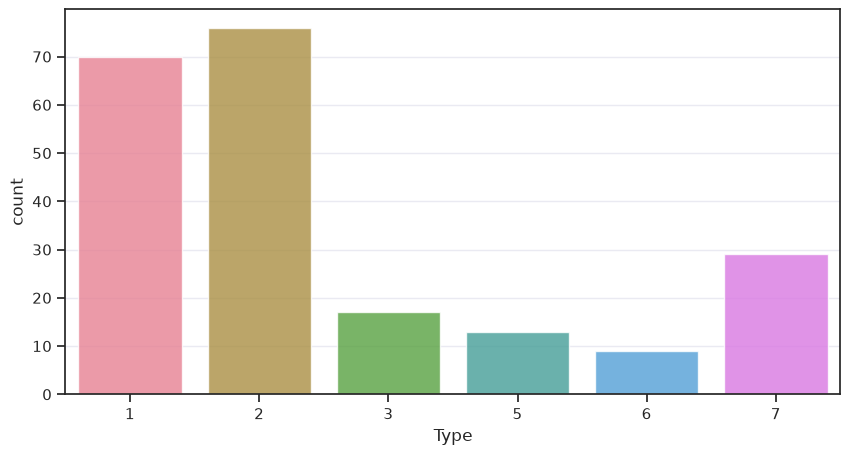

In [5]:
glass_palette = seaborn.color_palette("husl", len(pandas.unique(glass_dtf[glass_targetname])))
seaborn.countplot(data=glass_dtf, x=glass_targetname, hue=glass_targetname,
                 palette=glass_palette, alpha=0.8, legend=None);

The distribution of samples across the different glass types if clearly not uniform. The vast majority of samples come from building windows, produced using the float glass process (type 1) or otherwise (type 2). The third most frequent type consists of glass from headlamps (type 7). Next comes float glass from vehicle windows (type 3), followed by glass from containers (type 5) and from tableware (type 6). There are no samples from vehicle windows that are not float glass (type 4) in this dataset.

For each sample, we sum the weight percents across the eight different oxides, and check the range of the resulting values.

In [6]:
totals = glass_dtf[["Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]].sum(axis=1)
print(f"The sum of weight percents across the different oxides is between {totals.min():.2f} and {totals.max():.2f}")

The sum of weight percents across the different oxides is between 99.02 and 100.10


Up to rounding errors, the weight percents sum to a hundred, which makes sense.
That also means that the values are not independent, we could drop one of the oxides and recalculate its weight percents from the remaining seven.

We show descriptive statistics, excluding the `Type` column by name. Indeed, although this column contains numerical values, they represent categories and the order between the values is not actually meaningful.

For the refractive index and each oxide, the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [7]:
glass_dtf.drop(columns="Type").describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


The refractive index (RI) takes values between 1.511 and 1.534. The main component of glass is silicon (Si, not to be confused with silicone), making up between two-third and three-quarters of the weight of the samples. Sodium (Na) and calcium (Ca) are the next most common components of glass, followed by aluminum (Al), all three of which are present in all samples, albeit in varying amounts. On the other hand, magnesium (Mg), potassium (K), barium (Ba) and iron (Fe) are present in small quantities in some samples and absent from others, as visible from the minimum value (min) equal to zero in each of the corresponding four columns.

Next, we plot the correlation matrix, showing the correlation between every pair of attributes. We sort the rows and columns by the absolute value of the correlation with the target, so that attributes that are more strongly correlated with the type of glass, either positively or negatively, come first when going from the top to the bottom and from the left to the right of the matrix.

We use the `coolwarm` color map, scaled from -1 to 1, the full range of possible correlations, so that bright blue and red represent respectively strong negative and strong positive correlations, while intermediate correlation values are depicted with more muted shades, with gray indicating a correlation equal to zero, i.e. a pair of variables that are not linearly dependent.

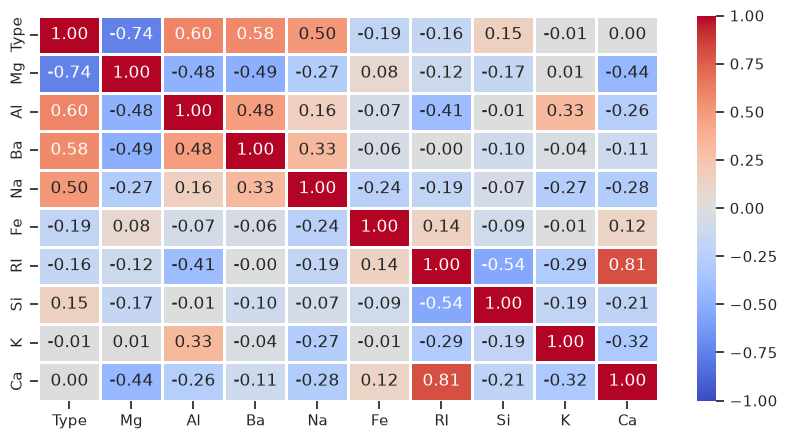

In [8]:
crm = glass_dtf.corr()
sorted_columns = crm[glass_targetname].abs().sort_values(ascending=False).index
sorted_features = sorted_columns[1:]
seaborn.heatmap(crm.loc[sorted_columns,sorted_columns], linewidth=.8,
                vmin=-1, vmax=1, cmap="coolwarm",
                annot=True, fmt=".2f");

Magnesium (Mg) has a fairly strong negative correlation with the glass type (-0.74), whereas aluminum (Al), barium (Ba) and potassium (K) are positively correlated with the glass type (0.60, 0.58 and 0.50, respectively). This indicates that glass of types denoted with small integers contain relatively higher percentages of magnesium and lower percentages of aluminum, barium and potassium as compared to glass of types denoted with larger integers. Obviously, this depends on the code used to represent types of glass, which is essentially arbitrary, as far as we can tell.

We can also see that the refractive index (RI) has a strong positive correlation with the amount of calcium (Ca, 0.81) and a more limited negative correlation with the amount of silicon (Si, -0.54).

We show the distribution of values for the refractive index and each of the eight oxides, with a separate boxplot for each glass type.
We keep the attributes sorted by decreasing absolute correlations with the type of glass.

When using the defaults parameters for drawing [boxplots](https://en.wikipedia.org/wiki/Box_plot), each box spans from the *lower quartile* (also first quartile *Q1*, or 25th percentile) to the *upper quartile* (also third quartile *Q3*, or 75th percentile). The difference between the two, corresponding to the height of the box, is known as the *interquartile range* (*IR*). *Wiskers*, spanning below and above the box, correspond respectively to the lower quartile minus one and a half interquartile range (*Q1 - 1.5 IR*) and the upper quartile plus one and a half interquartile range (*Q3 + 1.5 IR*). Values outside of that range are typically considered to be outliers, depicted as circles and known as *fliers*. The line inside the box represents the *median* (also second quartile *Q2*, or 50th percentile), i.e. the middle value.

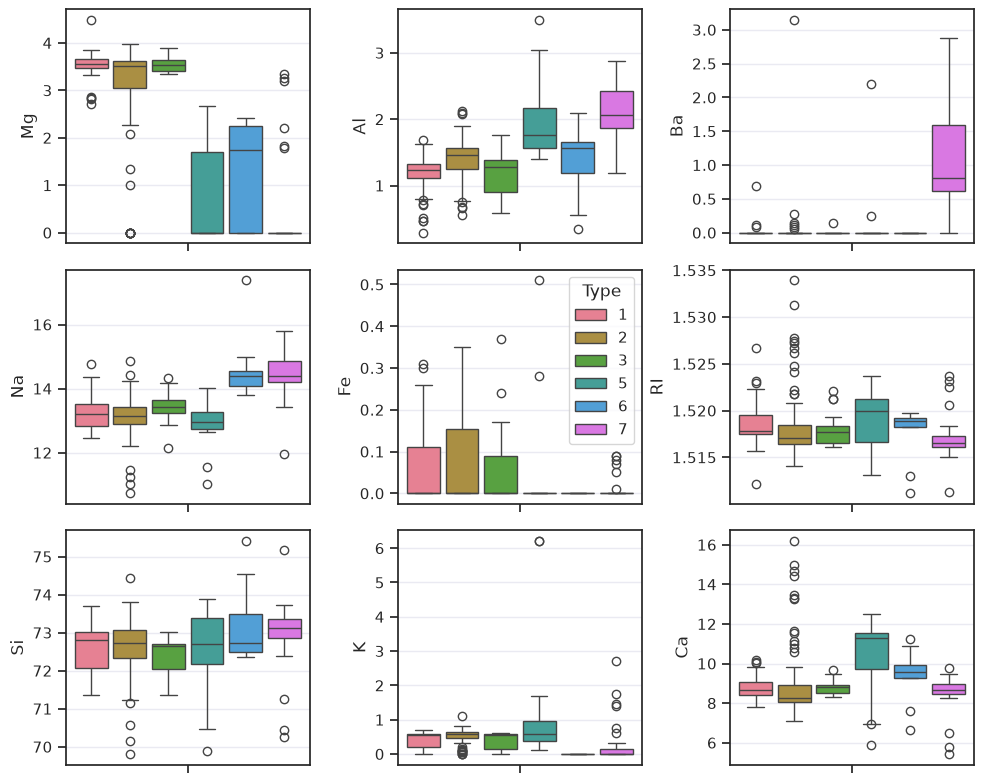

In [9]:
f, axes = plt.subplots(len(sorted_features)//3, 3)
for ci, c in enumerate(sorted_features):
    seaborn.boxplot(glass_dtf, y=c, hue=glass_targetname,
                    ax=axes[ci//3, ci%3], width=0.95, dodge=True, gap=0.15,
                    palette=glass_palette, legend=(ci==4))
f.set_figheight(8)
f.tight_layout()

Comparing the scale of the vertical axis of the middle panel to other panels, we see that it has the smallest values, indicating that iron (Fe) is only present in very small amounts if at all.
The median value of iron (Fe) weight percent (indicated by a line inside the box) is zero for all glass types. The third quartile (or 75th percentile, corresponding to the upper end of the box) is non zero for types 1, 2 and 3 and zero for types 5, 6 and 7. Few samples have exceptionally high values, depicted with circles as fliers.
In summary, iron is present in less than half of the samples from building and vehicle windows (types 1, 2 and 3) and absent from samples from other types of glass, with few exceptions.

Magnesium (Mg) is clearly more present in samples from building and vehicle windows (types 1, 2 and 3). Sodium (Na) is more present in samples from tableware and headlamps (types 6 and 7). Aluminum is also over-represented in samples from headlamps (type 7) but also, to a lower extent, in samples from containers (type 5), whereas barium (Ba) is only present in headlamp glass (type 7). This explains the correlations observed previously between these oxides weight percents and the type of glass.

Calcium (Ca) is over-represented in samples from containers (type 5).
The distribution of calcium (Ca) and refractive index (RI) are very similar, as could be expected from the high positive correlation.

The median value of silicon (Si) weight percent is almost the same for all glass types, about 72.8, the median value of potassium (K) weight percent is very similar among building and vehicle windows (types 1, 2 and 3) as well as containers (type 5), around 0.75.

Finally, we show some scatter plots. It would be overwhelming to display plots for all pairs of attributes. Instead, we show scatter plots for attributes that are strongly correlated with the type of glass, as columns in the grid of plots, against attributes that are more weakly correlated with it, as rows.

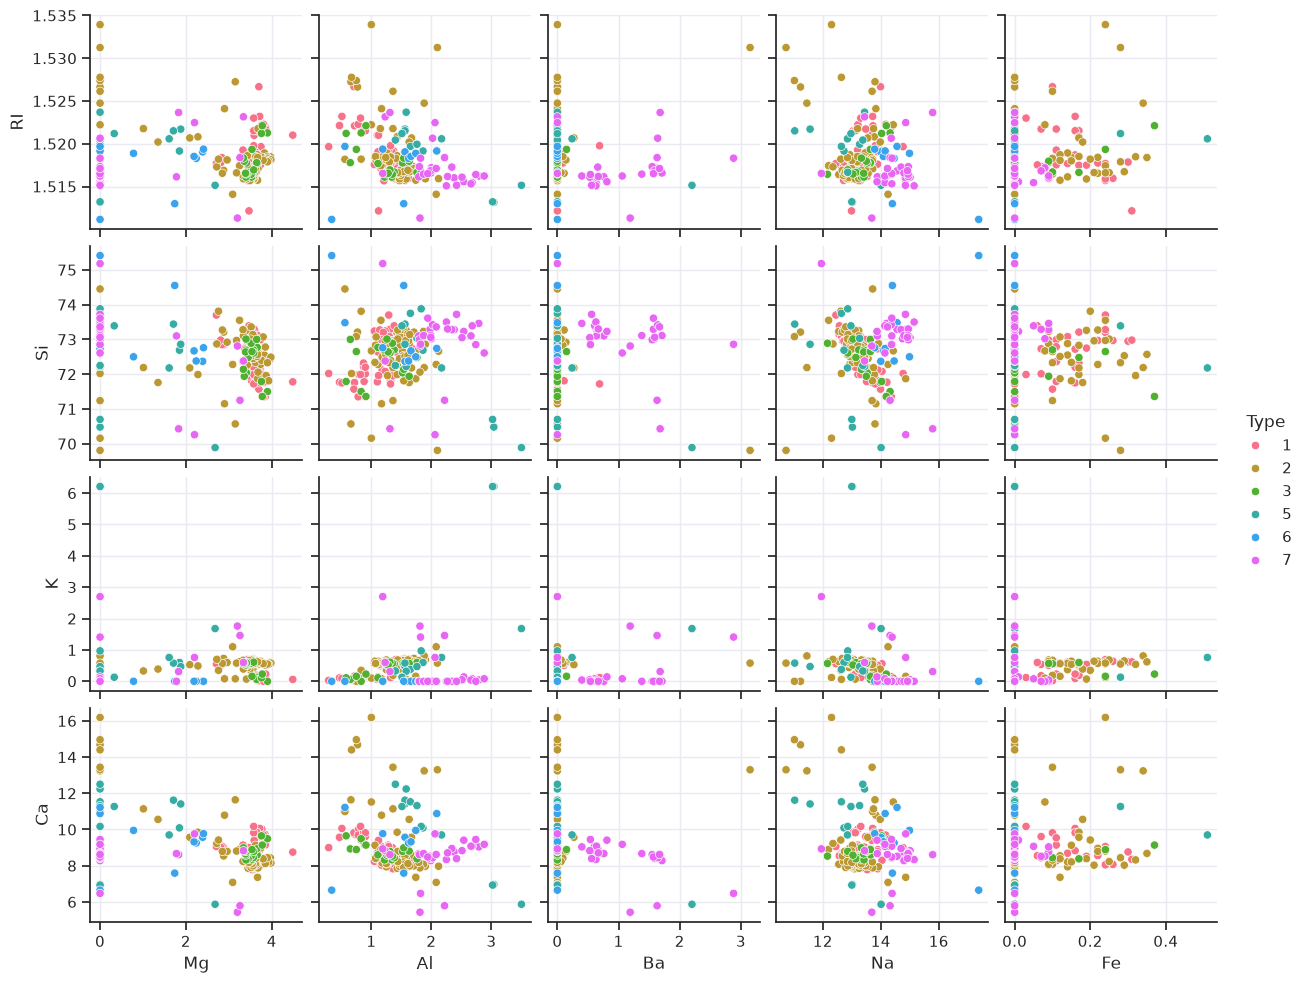

In [10]:
seaborn.pairplot(glass_dtf, hue=glass_targetname, x_vars=sorted_features[:5], y_vars=sorted_features[5:],
                palette=glass_palette);

A large number of points are aligned horizontally at zero for plots where the x-axis represents either magnesium (Mg), barium (Ba) or iron (Fe) weight percent, showing the large number of samples where these oxides are absent.

Overall, the scatter plots do not provide much information about the distribution of values beyond what we previously observed. In particular, they do not reveal any clear cluster structure.